# Distributed Ridge Regression
## Parameter Definition and Centralized Optimization
The problem is defined as

$$
\min_{x \in \mathbb{R}^d} \quad \frac{1}{4} \sum_{i = 1}^4 (u_i^\top x - v_i)^2 + \rho \| x \|^2
$$

where the solution is denoted as $x^*$.

In [1]:
import numpy as np
import numpy.typing as npt

dim = 10

# Should be consistent with the definition in the graph server
from conops import Graph

L = np.array([[2, -1, 0, -1], [-1, 2, -1, 0], [0, -1, 2, -1], [-1, 0, -1, 2]])
W = np.eye(4) - L * 0.2

graph = Graph.from_mixing_matrix(W, transport="tcp")
n_nodes = graph.number_of_nodes
nodes = graph.nodes

import numpy.random as npr

npr.seed(0)

rho = 0.01
u = {i: npr.uniform(-1, 1, dim) for i in nodes}
x_tilde = {i: 0.1 * (int(i) - 1) * np.ones(dim) for i in nodes}
epsilon = {i: npr.normal(0, 5) for i in nodes}
v = {i: u[i] @ x_tilde[i] + epsilon[i] for i in nodes}

import cvxpy as cp

x = cp.Variable(dim)

loss = cp.sum([(u[i] @ x - v[i]) ** 2 for i in nodes]) / n_nodes
regularizer = rho * cp.sum_squares(x)

prob = cp.Problem(cp.Minimize(loss + regularizer))
prob.solve(cp.OSQP)

x_star: npt.NDArray[np.float64] = x.value  # type: ignore

print(f"Optimal solution: {x_star}")

Optimal solution: [-0.92907018  1.82395728 -2.34861204 -1.14665289 -2.47729986  3.64587729
  2.57938462 -2.66468855 -3.83712911 -0.87901971]


## Benchmarking Distributed Optimization Algorithms

In this section, we benchmark the distributed optimization algorithms `EXTRA`, `NIDS`, `DIGing`, `AugDGM`, `WE`, and `RGT` on the ridge regression problem.
Each algorithm is executed with its respective step size, and their performance is compared in terms of mean squared error (MSE)

$$
\frac{1}{4d} \sum_{i = 1}^{4} || x_i - x^* ||^2
$$

over iterations, where $x_i, x^* \in \mathbb{R}^d$.

The network topology is a ring, and the gossip matrix is defined as $W = I - 0.2L$, with $L$ being the Laplacian matrix of the graph.

In [ ]:
import ray

ray.init(address="auto")
# or ray.init(address="auto") for multi-node setup

import typing


@ray.remote
class Agent:
    def __init__(
        self,
        node_id: str,
        dimension: int,
        u_i: npt.NDArray[np.float64],
        v_i: npt.NDArray[np.float64],
        rho_i: float,
        transport: typing.Literal["tcp", "ipc"],
    ):
        self.u_i = u_i
        self.v_i = v_i
        self.dim = dimension
        self.rho = rho_i

        from conops import NodeHandle
        from conops.transform import GaussianNoise

        tranform = GaussianNoise(scale=0.01)
        self.handle = NodeHandle(node_id, transform=tranform, transport=transport)

        self.max_iter = 2000

        from dco import Optimizer, EXTRA, NIDS, DIGing, AugDGM, RGT, RAugDGM, WE, AtcWE

        self.optim_cls: dict[str, type[Optimizer]] = {
            "EXTRA": EXTRA,
            "NIDS": NIDS,
            "DIGing": DIGing,
            "AugDGM": AugDGM,
            "RGT": RGT,
            "RAugDGM": RAugDGM,
            "WE": WE,
            "AtcWE": AtcWE,
        }

    def lasso(self, optim_name: str, gam: float) -> npt.NDArray[np.float64]:
        x_i = np.zeros((self.max_iter, self.dim), dtype=np.float64)

        # Define loss function
        def f(var: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
            return (self.u_i @ var - self.v_i) ** 2 + self.rho * var @ var

        # Create optimizer and run iterations
        optimizer = self.optim_cls[optim_name](f, self.handle, gam)

        optimizer.init(x_i[0])

        for k in range(self.max_iter - 1):
            x_i[k + 1] = optimizer.step(x_i[k])

        return x_i


import logging

logging.basicConfig(level=logging.INFO)

from conops import bootstrap

bootstrap(graph)
agents = {i: Agent.remote(i, dim, u[i], v[i], rho, "tcp") for i in nodes}

2026-04-14 18:16:55,310	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-14 18:16:55,320	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 192.168.1.111:6379...
2026-04-14 18:16:55,363	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at 127.0.0.1:8265 
/home/rui/code/discoopt/.venv/lib/python3.10/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


INFO:conops.bootstrap:Graph 'default' running on: 192.168.1.112:45675
INFO:conops.discovery:Registered graph service with name 'default'
INFO:conops.bootstrap:Node '3' joined graph 'default' from 192.168.1.103:36335.
INFO:conops.bootstrap:Node '4' joined graph 'default' from 192.168.1.106:43243.
INFO:conops.bootstrap:Node '1' joined graph 'default' from 192.168.1.110:39275.
INFO:conops.bootstrap:Node '2' joined graph 'default' from 192.168.1.110:37945.
INFO:conops.bootstrap:Graph 'default' registration complete.
INFO:conops.bootstrap:Sent neighbor info to all nodes in graph 'default'.
INFO:conops.discovery:Unregistered graph service with name 'default'
(Agent pid=3277, ip=192.168.1.103) Exception raised in creation task: The actor died because of an error raised in its creation task, ray::Agent.__init__() (pid=3277, ip=192.168.1.103, actor_id=5bd71d6640361ba44dfdcc9613000000, repr=<__main__.Agent object at 0xffff740b9390>)
(Agent pid=3277, ip=192.168.1.103)   File "/tmp/ipykernel_2956/

In [10]:
step_sizes = {
    "EXTRA": 0.16,
    "NIDS": 0.21,
    "DIGing": 0.11,
    "AugDGM": 0.31,
    "WE": 0.17,
    "RGT": 0.11,
}

local_histories: dict[str, list[npt.NDArray[np.float64]]] = {}

for alg, gam in step_sizes.items():
    refs = [agent.lasso.remote(alg, gam) for agent in agents.values()]
    local_histories[alg] = ray.get(refs)

    print(f"Algorithm: {alg}, Step size: {gam}, Finished!")

ActorDiedError: The actor died because of an error raised in its creation task, [36mray::Agent.__init__()[39m (pid=2950, ip=192.168.1.107, actor_id=de5d1d7c7315d67345e2774012000000, repr=<__main__.Agent object at 0xffff742b5300>)
  File "/tmp/ipykernel_1422/3527952777.py", line 33, in __init__
ImportError: cannot import name 'Optimizer' from 'dco' (/home/turtlebot/distributed_ws/.venv/lib/python3.10/site-packages/dco/__init__.py)

In [8]:
ray.shutdown()

## Plot results

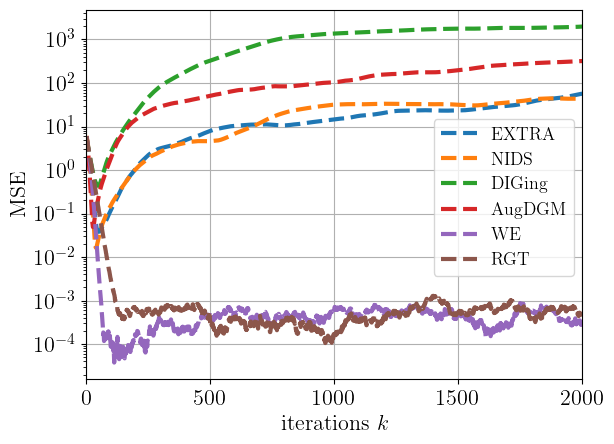

In [5]:
import matplotlib.pyplot as plt
from numpy import mean, stack

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 13,
    }
)

fig, ax = plt.subplots()

line_options = {"linewidth": 3, "linestyle": "--"}

hh: list[npt.NDArray[np.float64]] = []

for algorithm, histories in local_histories.items():
    # shape: (n_nodes, n_iter, dim)
    stacked_histories = stack(histories)
    # shape: (n_nodes, n_iter)
    mse_evolution_nodes = mean((stacked_histories - x_star) ** 2, axis=2)
    mse_evolution = mean(mse_evolution_nodes, axis=0)
    ax.semilogy(mse_evolution, label=algorithm, **line_options)
    hh.append(mse_evolution)

ax.set_xlim((0, 2000))
ax.set_xlabel("iterations $k$")
ax.set_ylabel("MSE")
ax.legend(loc=(0.7, 0.28))
ax.grid(True, which="major", linestyle="-", linewidth=0.8)